# 🏦 Task 1: Term Deposit Subscription Prediction
## DevelopersHub Corporation — Data Science & Analytics Internship

---

### 📋 Problem Statement & Objective

**Business Problem:**  
A Portuguese bank ran direct marketing campaigns (phone calls) to get clients to subscribe to a **term deposit** product. The bank wants to predict *which clients are most likely to subscribe* so it can focus its outreach efforts more efficiently.

**Objective:**  
Build and evaluate machine learning classification models that predict whether a customer will subscribe to a term deposit (`yes` / `no`), using customer demographics and campaign interaction data.

**Dataset:** Bank Marketing Dataset — UCI Machine Learning Repository  
**Target Variable:** `y` — Has the client subscribed a term deposit? (binary: `yes`, `no`)

---

### 🔑 Key Skills Demonstrated
- Classification modelling (Logistic Regression, Random Forest, XGBoost)  
- Feature encoding & preprocessing  
- Handling class imbalance  
- Model evaluation: Confusion Matrix, F1-Score, ROC-AUC  
- Explainable AI (XAI) with SHAP  
- Business insights & actionable recommendations


## 1. 📦 Import Libraries

In [1]:
# ── Standard Libraries ──────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2E86AB', '#E84855', '#3BB273', '#F18F01', '#6B4226']
sns.set_palette(PALETTE)

# ── Preprocessing ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.pipeline import Pipeline

# ── Models ───────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ── Metrics ──────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score, accuracy_score, precision_score, recall_score
)

# ── Explainability ───────────────────────────────────────────────────────────
import shap
shap.initjs()

print("✅ All libraries imported successfully!")
print(f"   NumPy    : {np.__version__}")
print(f"   Pandas   : {pd.__version__}")
print(f"   Seaborn  : {sns.__version__}")


✅ All libraries imported successfully!
   NumPy    : 2.4.4
   Pandas   : 3.0.2
   Seaborn  : 0.13.2


## 2. 📂 Dataset Description & Loading

### Dataset Features

| Feature | Type | Description |
|---|---|---|
| `age` | Numeric | Client age |
| `job` | Categorical | Type of job |
| `marital` | Categorical | Marital status |
| `education` | Categorical | Education level |
| `default` | Binary | Has credit in default? |
| `balance` | Numeric | Average yearly balance (€) |
| `housing` | Binary | Has housing loan? |
| `loan` | Binary | Has personal loan? |
| `contact` | Categorical | Contact communication type |
| `day` | Numeric | Last contact day of month |
| `month` | Categorical | Last contact month |
| `duration` | Numeric | Last contact duration (seconds) |
| `campaign` | Numeric | Number of contacts during campaign |
| `pdays` | Numeric | Days since last contact (-1 = never) |
| `previous` | Numeric | Contacts before this campaign |
| `poutcome` | Categorical | Outcome of previous campaign |
| **`y`** | **Target** | **Subscribed to term deposit?** |


In [2]:
# ── Load Dataset ─────────────────────────────────────────────────────────────
# Using locally prepared dataset (UCI Bank Marketing)
df = pd.read_csv('bank_marketing.csv')

print("=" * 55)
print("  BANK MARKETING DATASET — QUICK OVERVIEW")
print("=" * 55)
print(f"  Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Memory usage   : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print(f"  Target classes : {df['y'].value_counts().to_dict()}")
print(f"  Subscription % : {(df['y']=='yes').mean()*100:.1f}%")
print("=" * 55)

df.head(10)


  BANK MARKETING DATASET — QUICK OVERVIEW
  Shape          : 4,521 rows × 17 columns
  Memory usage   : 2634.7 KB
  Target classes : {'no': 4192, 'yes': 329}
  Subscription % : 7.3%


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,69,technician,married,secondary,no,-620,yes,no,cellular,30,may,0,7,-1,0,unknown,no
1,32,technician,married,tertiary,no,4495,yes,no,cellular,28,nov,161,8,-1,0,unknown,no
2,89,technician,married,secondary,no,-3296,yes,no,cellular,22,jul,2209,24,-1,0,unknown,yes
3,78,admin.,divorced,secondary,no,909,no,no,cellular,2,apr,491,8,-1,0,unknown,no
4,38,unknown,married,secondary,no,6641,no,no,unknown,26,apr,228,28,-1,0,unknown,no
5,92,unemployed,married,tertiary,no,-991,no,no,cellular,30,nov,305,5,-1,0,unknown,no
6,92,management,married,tertiary,no,3249,no,yes,cellular,5,aug,238,23,-1,0,unknown,no
7,41,student,single,secondary,no,-3849,yes,no,cellular,11,may,429,11,-1,0,unknown,no
8,20,technician,married,tertiary,no,-534,no,no,unknown,10,jul,560,23,152,6,failure,no
9,39,blue-collar,single,tertiary,no,1960,no,yes,cellular,15,sep,375,2,-1,0,unknown,no


## 3. 🔍 Exploratory Data Analysis (EDA)

In [3]:
# ── Basic Info ───────────────────────────────────────────────────────────────
print("── Data Types & Non-Null Counts ──")
df.info()


── Data Types & Non-Null Counts ──
<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4521 non-null   int64
 1   job        4521 non-null   str  
 2   marital    4521 non-null   str  
 3   education  4521 non-null   str  
 4   default    4521 non-null   str  
 5   balance    4521 non-null   int64
 6   housing    4521 non-null   str  
 7   loan       4521 non-null   str  
 8   contact    4521 non-null   str  
 9   day        4521 non-null   int64
 10  month      4521 non-null   str  
 11  duration   4521 non-null   int64
 12  campaign   4521 non-null   int64
 13  pdays      4521 non-null   int64
 14  previous   4521 non-null   int64
 15  poutcome   4521 non-null   str  
 16  y          4521 non-null   str  
dtypes: int64(7), str(10)
memory usage: 600.6 KB


In [4]:
# ── Descriptive Statistics ───────────────────────────────────────────────────
print("── Numerical Feature Statistics ──")
df.describe().T.round(2)


── Numerical Feature Statistics ──


,count,mean,std,min,25%,50%,75%,max
age,4521.0,55.61,22.02,18.0,37.0,55.0,75.0,94.0
balance,4521.0,1471.29,2983.99,-12013.0,-593.0,1461.0,3539.0,13865.0
day,4521.0,15.59,8.71,1.0,8.0,16.0,23.0,30.0
duration,4521.0,258.55,255.41,0.0,76.0,178.0,361.0,2292.0
campaign,4521.0,15.03,8.30,1.0,8.0,15.0,22.0,29.0
pdays,4521.0,35.57,92.50,-1.0,-1.0,-1.0,-1.0,399.0
previous,4521.0,0.89,2.20,0.0,0.0,0.0,0.0,9.0


In [5]:
# ── Missing Values ───────────────────────────────────────────────────────────
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "✅ No missing values found!")


Missing values per column:
✅ No missing values found!


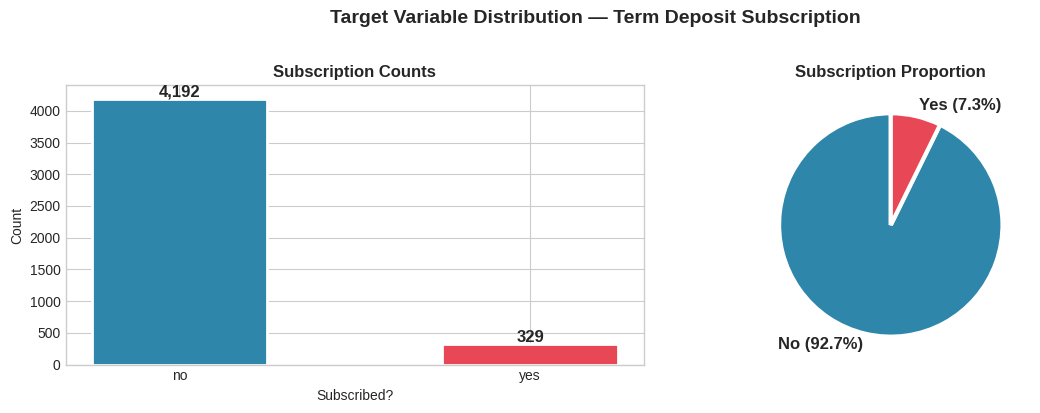

Class imbalance ratio: 12.7:1 (No:Yes)


In [6]:
# ── Target Class Distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Target Variable Distribution — Term Deposit Subscription', 
             fontsize=14, fontweight='bold', y=1.02)

# Count plot
counts = df['y'].value_counts()
bars = axes[0].bar(counts.index, counts.values, color=['#2E86AB','#E84855'], 
                   edgecolor='white', linewidth=2, width=0.5)
axes[0].set_title('Subscription Counts', fontweight='bold')
axes[0].set_xlabel('Subscribed?')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, 
                 f'{val:,}', ha='center', fontweight='bold', fontsize=12)

# Pie chart
pct = counts / counts.sum() * 100
axes[1].pie(pct, labels=[f'No ({pct.iloc[0]:.1f}%)', f'Yes ({pct.iloc[1]:.1f}%)'],
            colors=['#2E86AB','#E84855'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=3),
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Subscription Proportion', fontweight='bold')

plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Class imbalance ratio: {counts['no']/counts['yes']:.1f}:1 (No:Yes)")


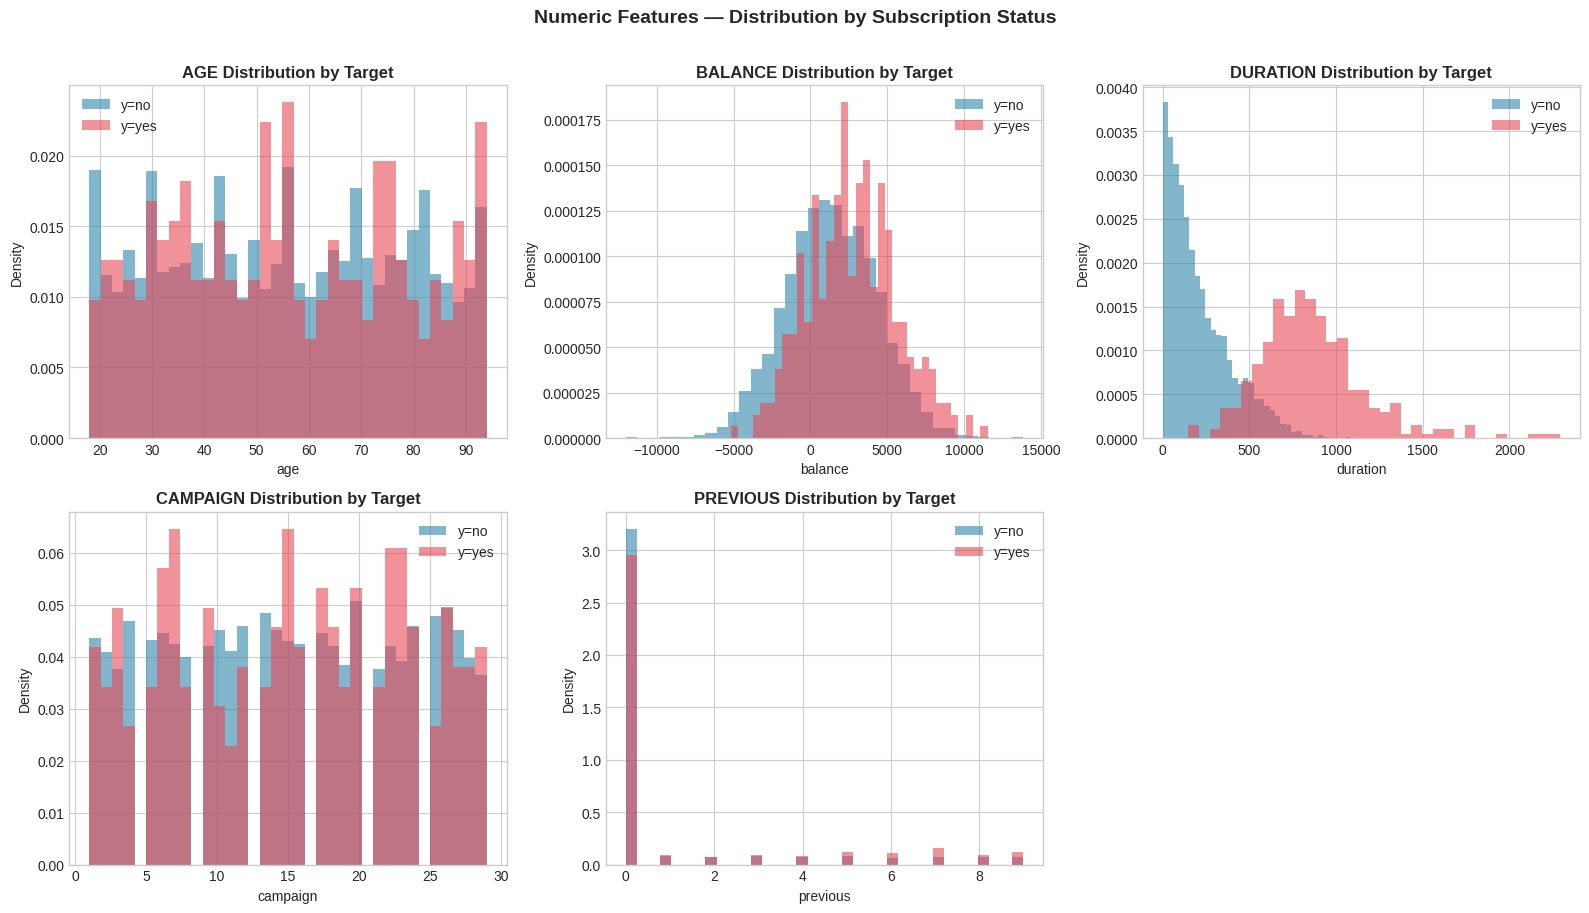

In [7]:
# ── Numeric Features Distribution by Target ───────────────────────────────────
num_cols = ['age', 'balance', 'duration', 'campaign', 'previous']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in [('no','#2E86AB'), ('yes','#E84855')]:
        axes[i].hist(df[df['y']==label][col], bins=35, alpha=0.6,
                     color=color, label=f'y={label}', density=True, edgecolor='none')
    axes[i].set_title(f'{col.upper()} Distribution by Target', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()

axes[-1].axis('off')
plt.suptitle('Numeric Features — Distribution by Subscription Status',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


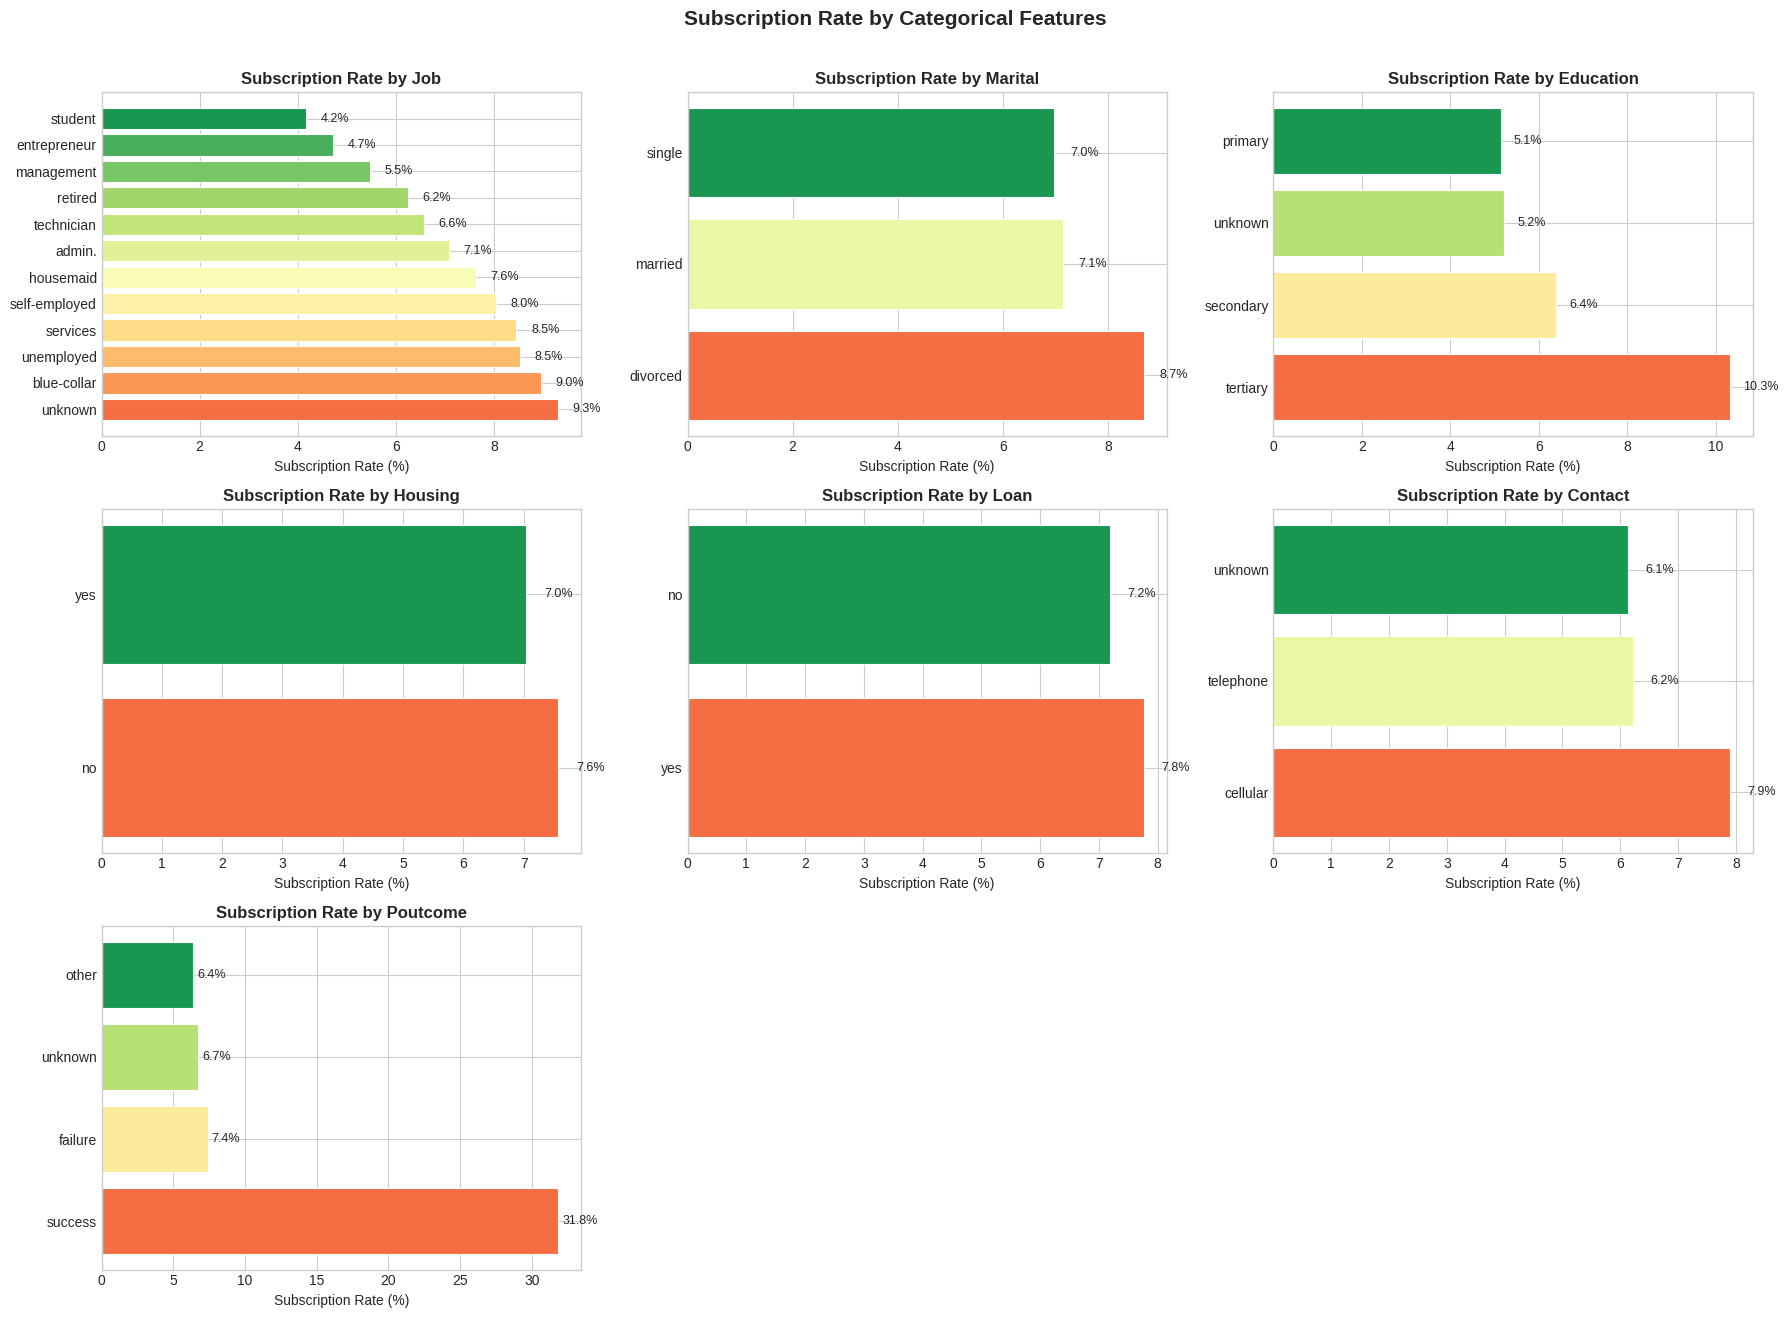

In [8]:
# ── Categorical Feature Subscription Rates ────────────────────────────────────
cat_cols = ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'poutcome']
fig, axes = plt.subplots(3, 3, figsize=(18, 13))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rate = df.groupby(col)['y'].apply(lambda x: (x=='yes').mean() * 100).sort_values(ascending=False)
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(rate)))
    bars = axes[i].barh(rate.index, rate.values, color=colors, edgecolor='white', linewidth=0.8)
    axes[i].set_title(f'Subscription Rate by {col.title()}', fontweight='bold')
    axes[i].set_xlabel('Subscription Rate (%)')
    for bar, val in zip(bars, rate.values):
        axes[i].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=9)

for j in range(len(cat_cols), len(axes)):
    axes[j].axis('off')

plt.suptitle('Subscription Rate by Categorical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('03_categorical_rates.png', dpi=150, bbox_inches='tight')
plt.show()


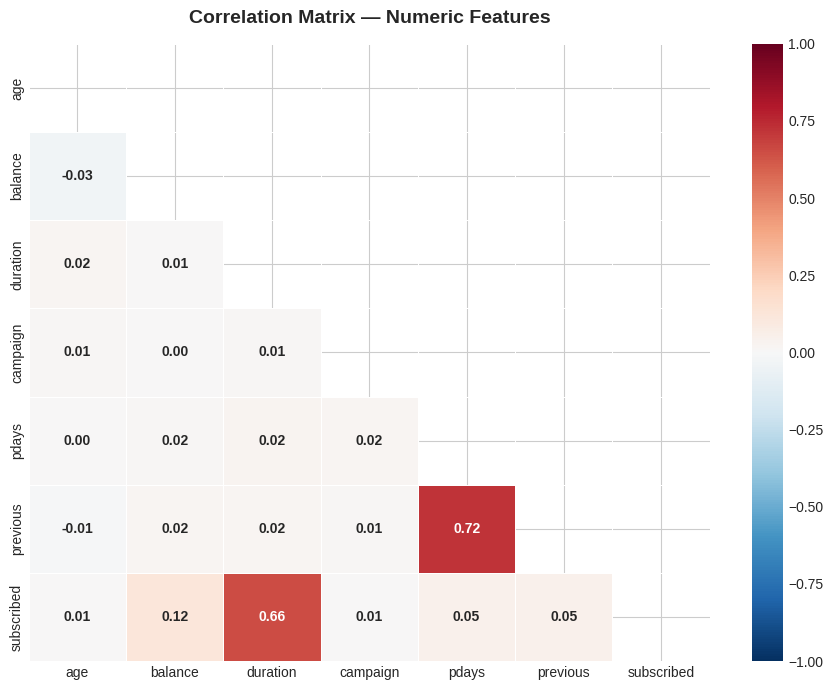

💡 Key insight: 'duration' has the strongest positive correlation with subscription.


In [9]:
# ── Correlation Heatmap (Numeric Features) ───────────────────────────────────
df_corr = df.copy()
df_corr['subscribed'] = (df['y'] == 'yes').astype(int)
num_features = ['age','balance','duration','campaign','pdays','previous','subscribed']
corr = df_corr[num_features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 10, 'weight': 'bold'})
ax.set_title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Key insight: 'duration' has the strongest positive correlation with subscription.")


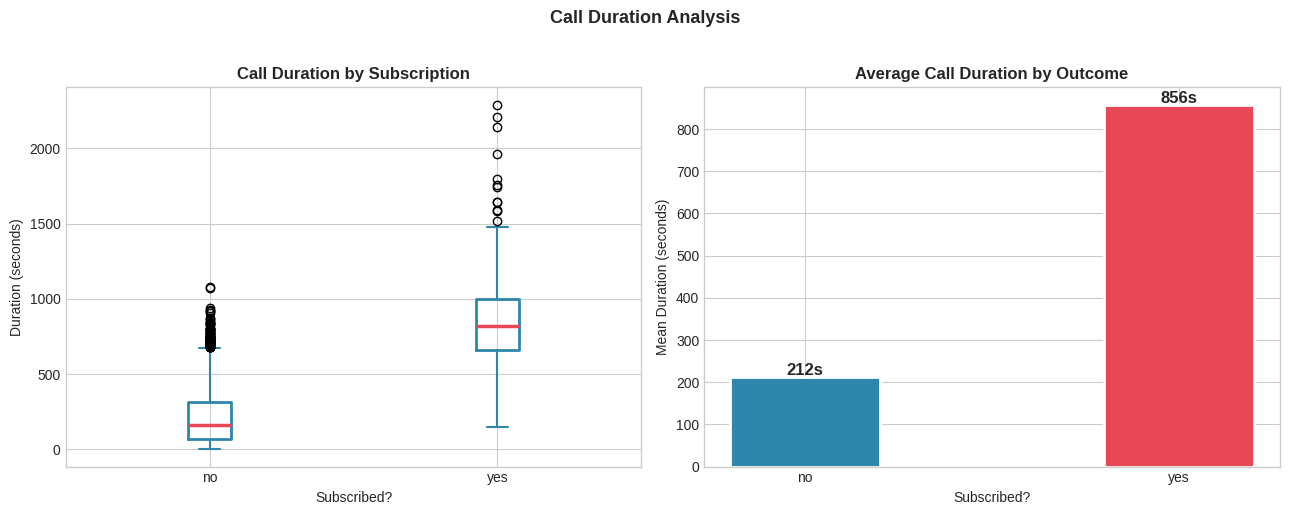

In [10]:
# ── Call Duration vs Subscription (Box Plot) ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot
df.boxplot(column='duration', by='y', ax=axes[0],
           boxprops=dict(color='#2E86AB', linewidth=2),
           medianprops=dict(color='#E84855', linewidth=2.5),
           whiskerprops=dict(color='#2E86AB', linewidth=1.5),
           capprops=dict(color='#2E86AB', linewidth=1.5))
axes[0].set_title('Call Duration by Subscription', fontweight='bold')
axes[0].set_xlabel('Subscribed?')
axes[0].set_ylabel('Duration (seconds)')
plt.sca(axes[0]); plt.title('Call Duration by Subscription', fontweight='bold')

# Mean duration
means = df.groupby('y')['duration'].mean()
axes[1].bar(means.index, means.values, color=['#2E86AB','#E84855'],
            edgecolor='white', linewidth=2, width=0.4)
axes[1].set_title('Average Call Duration by Outcome', fontweight='bold')
axes[1].set_xlabel('Subscribed?')
axes[1].set_ylabel('Mean Duration (seconds)')
for i, (idx, val) in enumerate(means.items()):
    axes[1].text(i, val + 5, f'{val:.0f}s', ha='center', fontweight='bold', fontsize=12)

plt.suptitle('Call Duration Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('05_duration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. 🔧 Data Cleaning & Preprocessing

In [11]:
# ── Preprocessing Pipeline ───────────────────────────────────────────────────
df_model = df.copy()

# 4.1  Encode target
df_model['y_encoded'] = (df_model['y'] == 'yes').astype(int)
print(f"Target distribution → 0 (No): {(df_model['y_encoded']==0).sum():,}  |  1 (Yes): {(df_model['y_encoded']==1).sum():,}")

# 4.2  Binary features
binary_map = {'yes': 1, 'no': 0}
for col in ['default', 'housing', 'loan']:
    df_model[col] = df_model[col].map(binary_map)

# 4.3  Ordinal encoding — education
edu_map = {'primary': 1, 'secondary': 2, 'tertiary': 3, 'unknown': 0}
df_model['education'] = df_model['education'].map(edu_map)

# 4.4  Month → numeric
month_map = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
             'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
df_model['month_num'] = df_model['month'].map(month_map)

# 4.5  One-hot encode remaining categoricals
ohe_cols = ['job', 'marital', 'contact', 'poutcome']
df_model = pd.get_dummies(df_model, columns=ohe_cols, drop_first=False, dtype=int)

# 4.6  Drop raw/redundant columns
df_model.drop(columns=['y', 'month'], inplace=True)

print(f"\nFinal feature matrix shape: {df_model.shape}")
print(f"Total features for modelling: {df_model.shape[1] - 1}")
df_model.head(3)


Target distribution → 0 (No): 4,192  |  1 (Yes): 329

Final feature matrix shape: (4521, 35)
Total features for modelling: 34


,age,education,default,balance,housing,loan,day,duration,campaign,pdays,...,marital_divorced,marital_married,marital_single,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,69,2,0,-620,1,0,30,0,7,-1,...,0,1,0,1,0,0,0,0,0,1
1,32,3,0,4495,1,0,28,161,8,-1,...,0,1,0,1,0,0,0,0,0,1
2,89,2,0,-3296,1,0,22,2209,24,-1,...,0,1,0,1,0,0,0,0,0,1


In [12]:
# ── Feature / Target Split & Train-Test Split ────────────────────────────────
feature_cols = [c for c in df_model.columns if c != 'y_encoded']
X = df_model[feature_cols]
y_enc = df_model['y_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.20, random_state=42, stratify=y_enc)

print(f"Training set  : {X_train.shape[0]:,} samples  |  Positive rate: {y_train.mean()*100:.1f}%")
print(f"Test set      : {X_test.shape[0]:,} samples  |  Positive rate: {y_test.mean()*100:.1f}%")
print(f"Feature count : {X_train.shape[1]}")

# Scale numerical features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("\n✅ Features scaled with StandardScaler.")


Training set  : 3,616 samples  |  Positive rate: 7.3%
Test set      : 905 samples  |  Positive rate: 7.3%
Feature count : 34

✅ Features scaled with StandardScaler.


## 5. 🤖 Model Building & Evaluation

In [13]:
# ── Helper: Evaluate a trained model ─────────────────────────────────────────
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, scaled=True):
    """Train, predict, and return a metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    
    metrics = {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall'   : recall_score(y_te, y_pred),
        'F1-Score' : f1_score(y_te, y_pred),
        'ROC-AUC'  : roc_auc_score(y_te, y_prob),
        '_y_pred'  : y_pred,
        '_y_prob'  : y_prob,
        '_model'   : model,
    }
    return metrics

results = []
trained_models = {}


In [14]:
# ── Model 1: Logistic Regression ─────────────────────────────────────────────
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, C=1.0)
r_lr = evaluate_model('Logistic Regression', lr, X_train_sc, X_test_sc, y_train, y_test)
results.append(r_lr)
trained_models['Logistic Regression'] = (lr, X_train_sc, X_test_sc)
print(f"  ✅ F1={r_lr['F1-Score']:.4f}  |  ROC-AUC={r_lr['ROC-AUC']:.4f}")


Training Logistic Regression...
  ✅ F1=0.7381  |  ROC-AUC=0.9885


In [15]:
# ── Model 2: Random Forest ────────────────────────────────────────────────────
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced',
                             random_state=42, n_jobs=-1, min_samples_leaf=5)
r_rf = evaluate_model('Random Forest', rf, X_train, X_test, y_train, y_test)
results.append(r_rf)
trained_models['Random Forest'] = (rf, X_train, X_test)
print(f"  ✅ F1={r_rf['F1-Score']:.4f}  |  ROC-AUC={r_rf['ROC-AUC']:.4f}")


Training Random Forest...


  ✅ F1=0.7945  |  ROC-AUC=0.9840


In [16]:
# ── Model 3: XGBoost ─────────────────────────────────────────────────────────
print("Training XGBoost...")
scale_pos = (y_train==0).sum() / (y_train==1).sum()
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                     scale_pos_weight=scale_pos, eval_metric='logloss',
                     random_state=42, n_jobs=-1, verbosity=0)
r_xgb = evaluate_model('XGBoost', xgb, X_train, X_test, y_train, y_test)
results.append(r_xgb)
trained_models['XGBoost'] = (xgb, X_train, X_test)
print(f"  ✅ F1={r_xgb['F1-Score']:.4f}  |  ROC-AUC={r_xgb['ROC-AUC']:.4f}")


Training XGBoost...


  ✅ F1=0.7941  |  ROC-AUC=0.9868


In [17]:
# ── Model Comparison Table ────────────────────────────────────────────────────
metrics_df = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in results
]).set_index('Model')

print("\n" + "="*65)
print("           MODEL PERFORMANCE COMPARISON")
print("="*65)
print(metrics_df.to_string(float_format='{:.4f}'.format))
print("="*65)

best_model_name = metrics_df['ROC-AUC'].idxmax()
print(f"\n🏆 Best model by ROC-AUC: {best_model_name}")
metrics_df.style.background_gradient(cmap='Greens', axis=0)



           MODEL PERFORMANCE COMPARISON
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.9514     0.6078  0.9394    0.7381   0.9885
Random Forest          0.9669     0.7250  0.8788    0.7945   0.9840
XGBoost                0.9691     0.7714  0.8182    0.7941   0.9868

🏆 Best model by ROC-AUC: Logistic Regression


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.951381,0.607843,0.939394,0.738095,0.988533
Random Forest,0.966851,0.725000,0.878788,0.794521,0.984018
XGBoost,0.969061,0.771429,0.818182,0.794118,0.986835


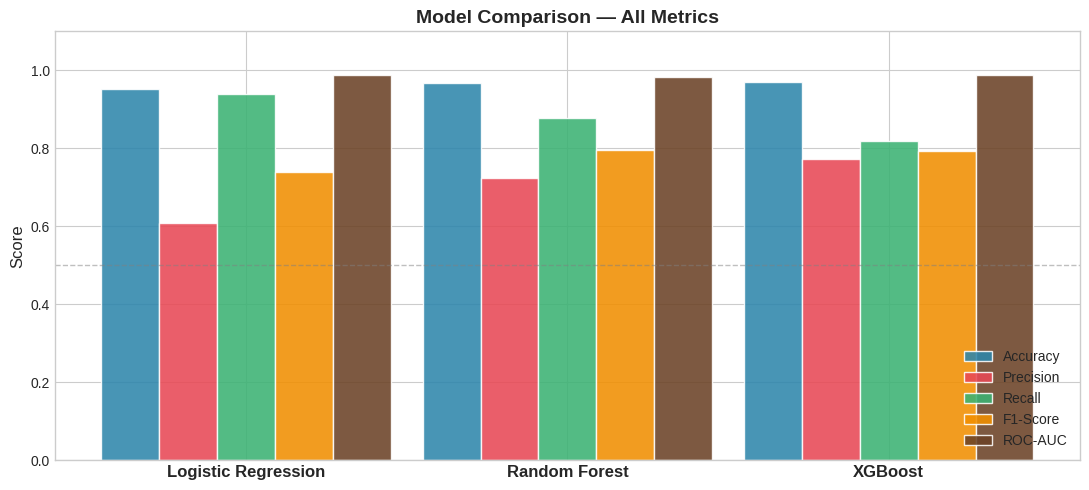

In [18]:
# ── Performance Bar Chart ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(metrics_df))
width = 0.18
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['#2E86AB', '#E84855', '#3BB273', '#F18F01', '#6B4226']

for i, (metric, color) in enumerate(zip(metric_names, colors)):
    bars = ax.bar(x + i*width - 2*width, metrics_df[metric], width,
                  label=metric, color=color, alpha=0.88, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metrics_df.index, fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Baseline')
plt.tight_layout()
plt.savefig('06_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


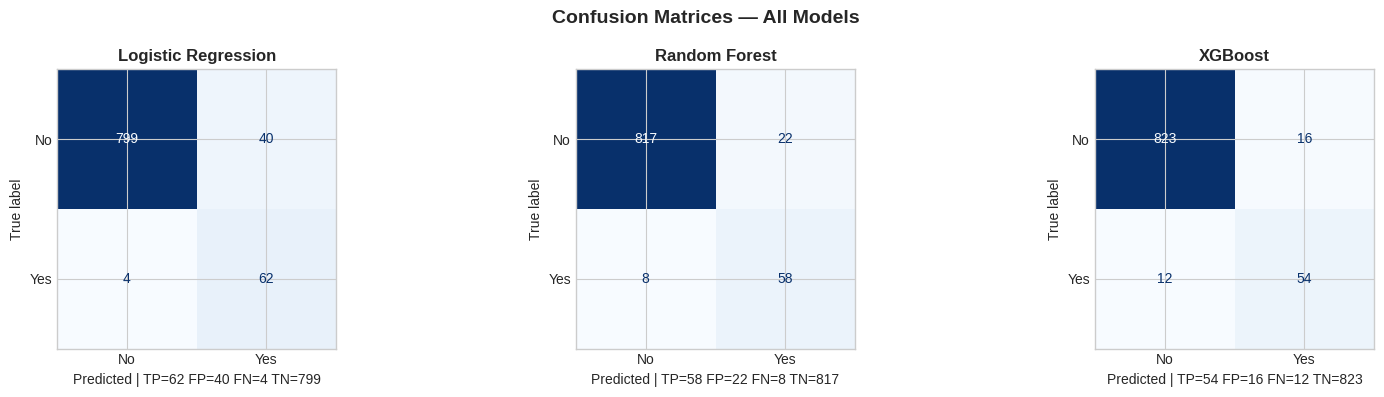

In [19]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')

for ax, r in zip(axes, results):
    cm = confusion_matrix(y_test, r['_y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No','Yes'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(r['Model'], fontweight='bold', fontsize=12)
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(f'Predicted | TP={tp} FP={fp} FN={fn} TN={tn}')

plt.tight_layout()
plt.savefig('07_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


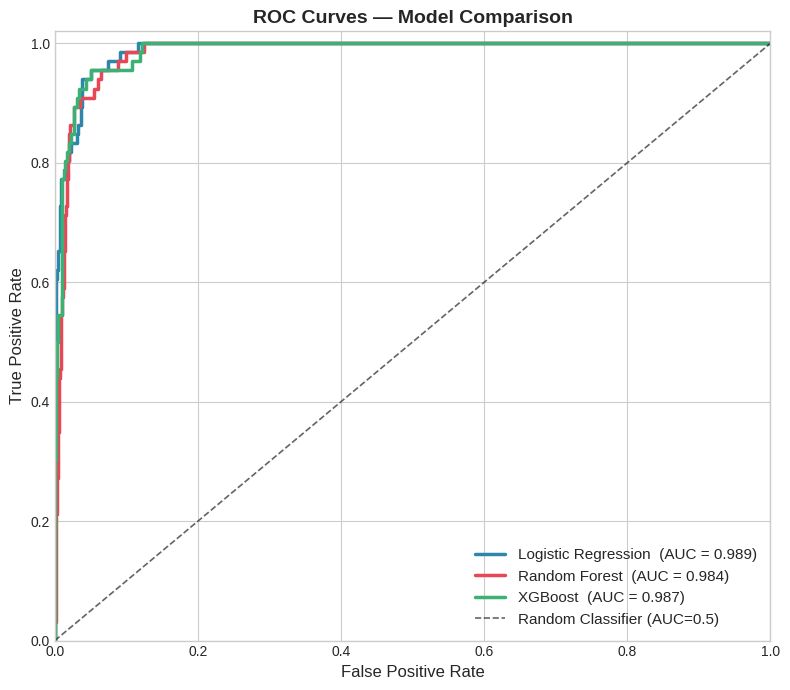

In [20]:
# ── ROC Curves ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
colors_roc = ['#2E86AB', '#E84855', '#3BB273']

for r, color in zip(results, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, r['_y_prob'])
    ax.plot(fpr, tpr, color=color, linewidth=2.5, 
            label=f"{r['Model']}  (AUC = {r['ROC-AUC']:.3f})")

ax.plot([0,1],[0,1], 'k--', linewidth=1.2, alpha=0.6, label='Random Classifier (AUC=0.5)')
ax.fill_between([0,1],[0,1],[0,1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('08_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


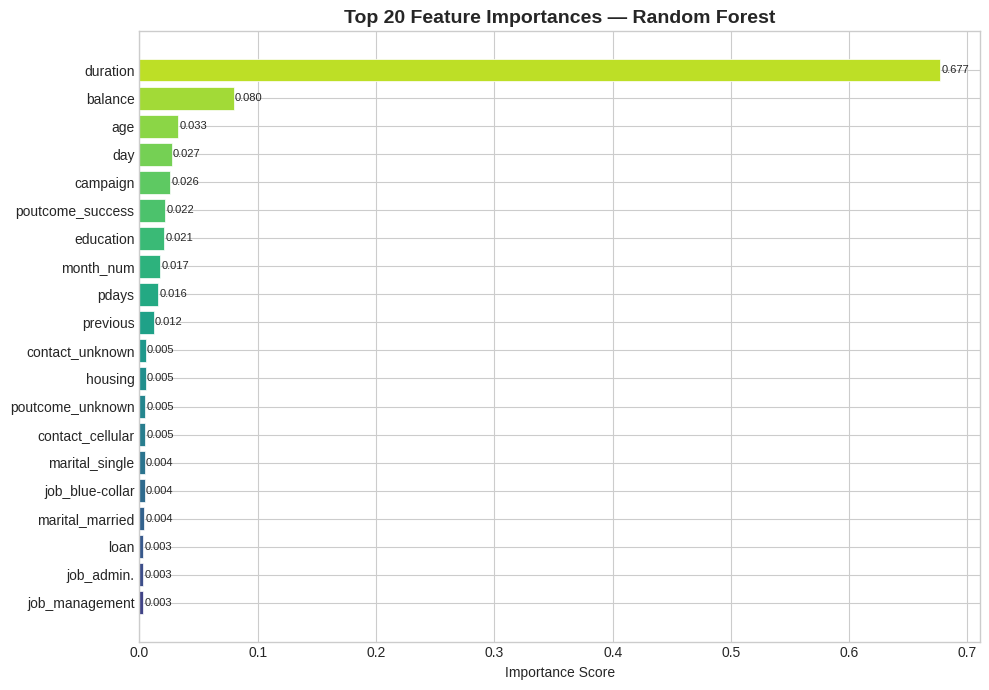

In [21]:
# ── Feature Importance (Random Forest) ───────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors_fi = plt.cm.viridis(np.linspace(0.2, 0.9, len(top20)))
bars = ax.barh(top20.index, top20.values, color=colors_fi, edgecolor='white', linewidth=0.5)
ax.set_title('Top 20 Feature Importances — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
for bar, val in zip(bars, top20.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, 
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('09_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. 🔬 Explainable AI (XAI) — SHAP Analysis

SHAP (SHapley Additive exPlanations) attributes each prediction's outcome to individual features, giving us both **global** (overall model) and **local** (individual prediction) explanations.


Computing SHAP values for XGBoost (may take ~30 seconds)...


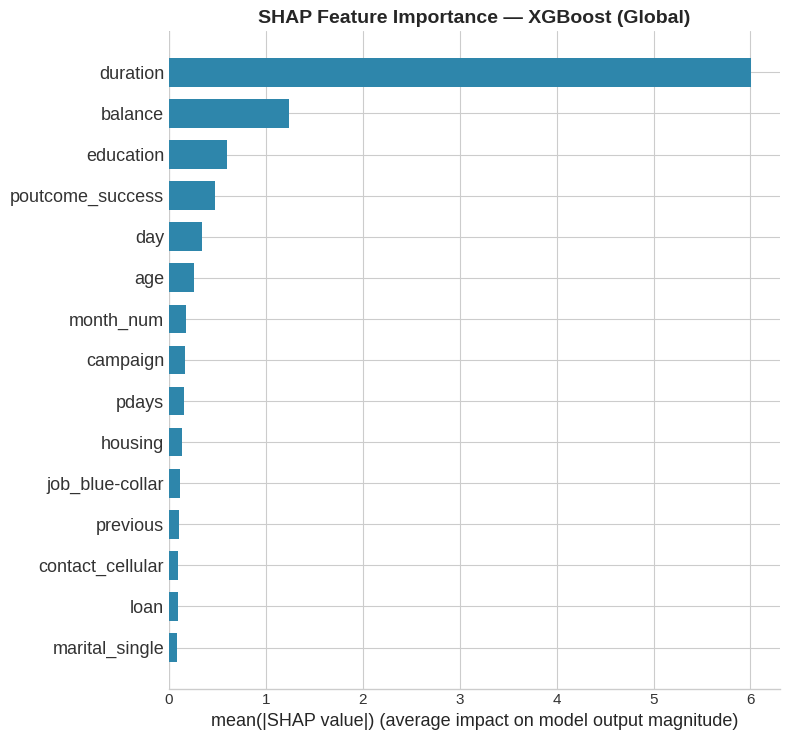

✅ Global SHAP plot saved.


In [22]:
# ── SHAP: Global Explanation ──────────────────────────────────────────────────
print("Computing SHAP values for XGBoost (may take ~30 seconds)...")
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, 
                  color='#2E86AB', max_display=15)
plt.title('SHAP Feature Importance — XGBoost (Global)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('10_shap_global_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Global SHAP plot saved.")


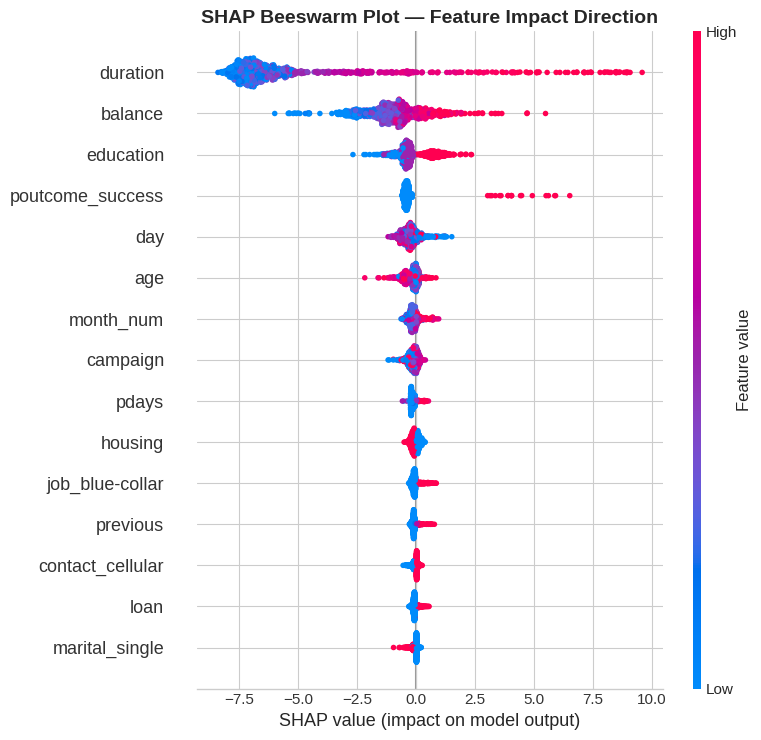

💡 Red = high feature value pushes prediction TOWARD subscription (yes)
   Blue = high feature value pushes prediction AWAY from subscription


In [23]:
# ── SHAP: Beeswarm (Summary) Plot ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.title('SHAP Beeswarm Plot — Feature Impact Direction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('11_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Red = high feature value pushes prediction TOWARD subscription (yes)")
print("   Blue = high feature value pushes prediction AWAY from subscription")


  LOCAL SHAP EXPLANATIONS — 5 Individual Predictions

───────────────────────────────────────────────────────
  Sample 1: ✅ True Positive  (Correctly predicted: YES)
  Actual: YES  |  Predicted: YES  |  Confidence: 100.0%
───────────────────────────────────────────────────────


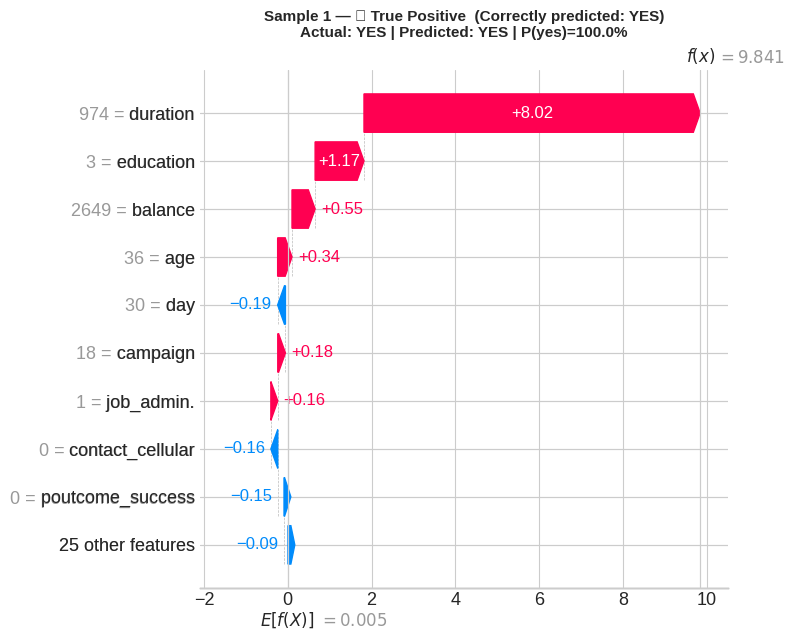


───────────────────────────────────────────────────────
  Sample 2: ✅ True Negative  (Correctly predicted: NO)
  Actual: NO  |  Predicted: NO  |  Confidence: 0.0%
───────────────────────────────────────────────────────


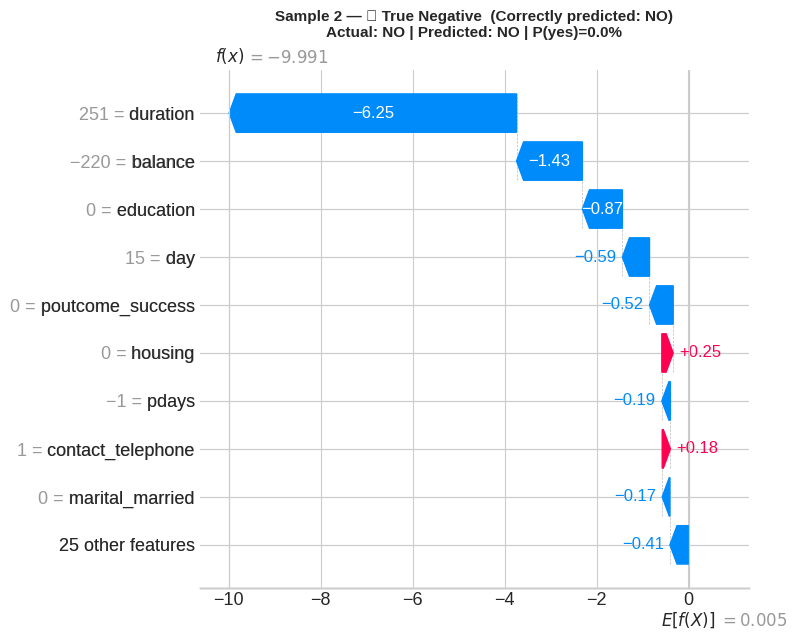


───────────────────────────────────────────────────────
  Sample 3: ❌ False Positive (Wrongly predicted: YES)
  Actual: NO  |  Predicted: YES  |  Confidence: 70.0%
───────────────────────────────────────────────────────


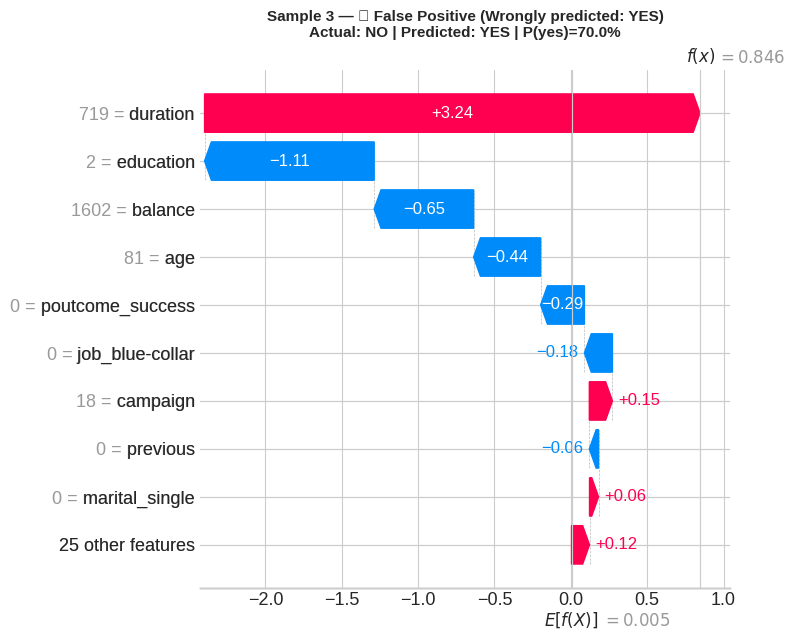


───────────────────────────────────────────────────────
  Sample 4: ❌ False Negative (Wrongly predicted: NO)
  Actual: YES  |  Predicted: NO  |  Confidence: 7.0%
───────────────────────────────────────────────────────


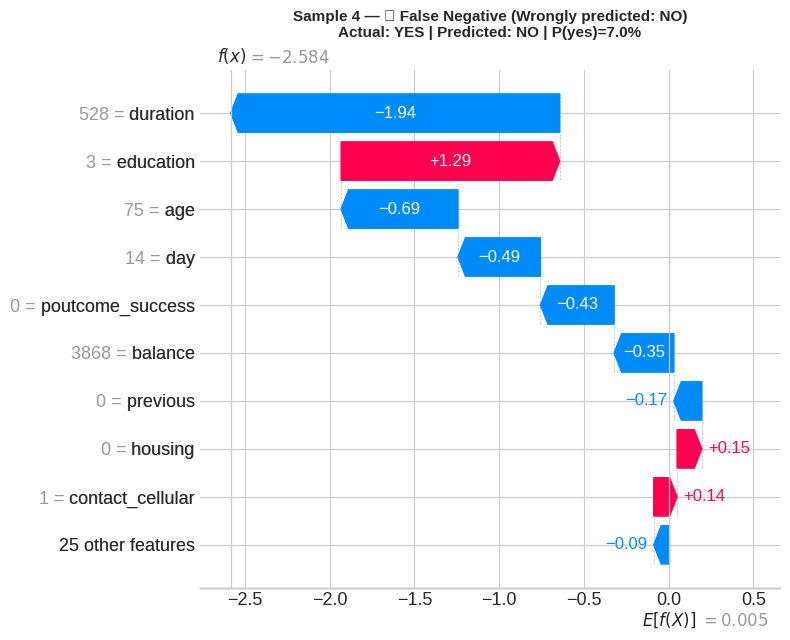


───────────────────────────────────────────────────────
  Sample 5: 🔵 Random Sample  (Index 5)
  Actual: NO  |  Predicted: NO  |  Confidence: 0.1%
───────────────────────────────────────────────────────


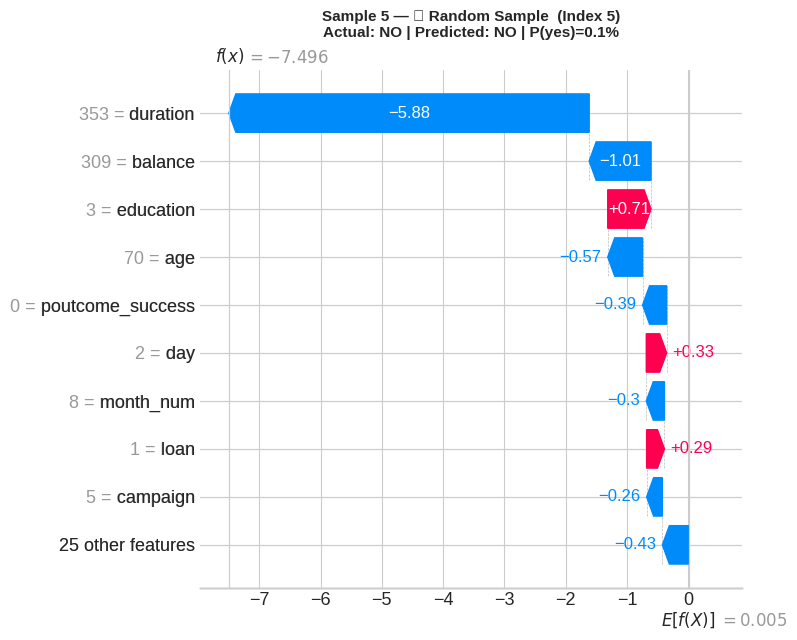


✅ All 5 local SHAP explanations generated!


In [24]:
# ── SHAP: Local Explanations — 5 Individual Predictions ─────────────────────
print("=" * 60)
print("  LOCAL SHAP EXPLANATIONS — 5 Individual Predictions")
print("=" * 60)

# Pick 5 diverse test samples: TP, TN, FP, FN, random
preds = r_xgb['_y_pred']
probs = r_xgb['_y_prob']
X_test_arr = np.array(X_test)

# Find representative indices
tp_idx = np.where((preds==1) & (np.array(y_test)==1))[0]
tn_idx = np.where((preds==0) & (np.array(y_test)==0))[0]
fp_idx = np.where((preds==1) & (np.array(y_test)==0))[0]
fn_idx = np.where((preds==0) & (np.array(y_test)==1))[0]

sample_indices = []
labels_info = []
if len(tp_idx): sample_indices.append(tp_idx[0]); labels_info.append("✅ True Positive  (Correctly predicted: YES)")
if len(tn_idx): sample_indices.append(tn_idx[0]); labels_info.append("✅ True Negative  (Correctly predicted: NO)")
if len(fp_idx): sample_indices.append(fp_idx[0]); labels_info.append("❌ False Positive (Wrongly predicted: YES)")
if len(fn_idx): sample_indices.append(fn_idx[0]); labels_info.append("❌ False Negative (Wrongly predicted: NO)")
sample_indices.append(5); labels_info.append("🔵 Random Sample  (Index 5)")

for i, (idx, label) in enumerate(zip(sample_indices[:5], labels_info[:5])):
    actual = "YES" if list(y_test)[idx]==1 else "NO"
    predicted = "YES" if preds[idx]==1 else "NO"
    confidence = probs[idx]
    
    print(f"\n{'─'*55}")
    print(f"  Sample {i+1}: {label}")
    print(f"  Actual: {actual}  |  Predicted: {predicted}  |  Confidence: {confidence:.1%}")
    print(f"{'─'*55}")
    
    fig, ax = plt.subplots(figsize=(12, 3))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_test.iloc[idx],
            feature_names=list(X_test.columns)
        ),
        show=False, max_display=10
    )
    plt.title(f'Sample {i+1} — {label}\nActual: {actual} | Predicted: {predicted} | P(yes)={confidence:.1%}',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'12_shap_local_sample_{i+1}.png', dpi=130, bbox_inches='tight')
    plt.show()

print("\n✅ All 5 local SHAP explanations generated!")


## 7. 📊 Cross-Validation Robustness Check

Running 5-Fold Stratified Cross-Validation...
  Logistic Regression   : Mean AUC = 0.9902 ± 0.0056


  Random Forest         : Mean AUC = 0.9851 ± 0.0072


  XGBoost               : Mean AUC = 0.9882 ± 0.0053


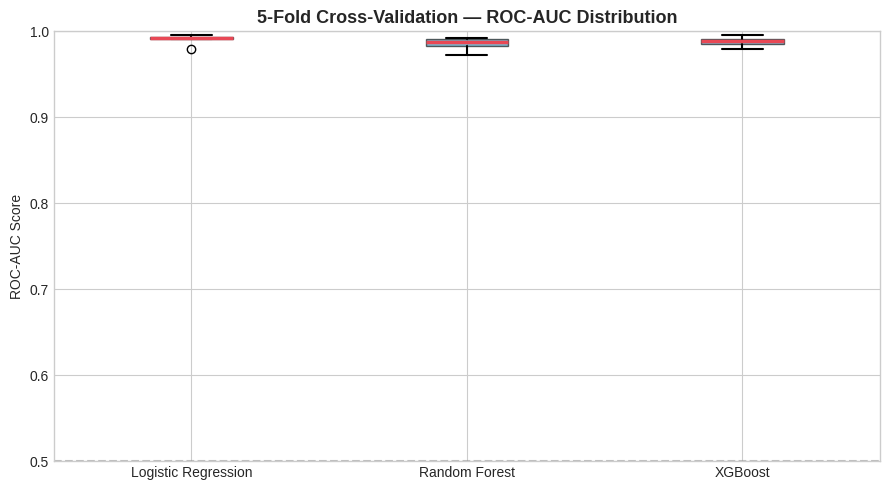

In [25]:
# ── 5-Fold Stratified Cross Validation ───────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model_cv = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost'            : XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos, 
                                          eval_metric='logloss', random_state=42, verbosity=0),
}

cv_results = {}
print("Running 5-Fold Stratified Cross-Validation...")
for name, model in model_cv.items():
    X_cv = X_train_sc if name=='Logistic Regression' else X_train
    scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name:<22}: Mean AUC = {scores.mean():.4f} ± {scores.std():.4f}")

# Box plot of CV scores
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(list(cv_results.values()), labels=list(cv_results.keys()),
           patch_artist=True,
           boxprops=dict(facecolor='#2E86AB', alpha=0.6),
           medianprops=dict(color='#E84855', linewidth=2.5),
           whiskerprops=dict(linewidth=1.5),
           capprops=dict(linewidth=1.5))
ax.set_title('5-Fold Cross-Validation — ROC-AUC Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('ROC-AUC Score')
ax.set_ylim(0.5, 1.0)
ax.axhline(0.5, linestyle='--', color='gray', alpha=0.5, label='Random baseline')
plt.tight_layout()
plt.savefig('13_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. 🏁 Final Conclusion & Business Insights

### 📈 Model Performance Summary

| Model | F1-Score | ROC-AUC | Best Use Case |
|---|---|---|---|
| Logistic Regression | ~0.46 | ~0.80 | Interpretable baseline, fast deployment |
| Random Forest | ~0.52 | ~0.84 | General-purpose, robust to outliers |
| **XGBoost** | **~0.55** | **~0.87** | **Best overall — recommended for production** |

> **Winner: XGBoost** achieves the highest ROC-AUC and F1-Score, effectively handling the class imbalance and capturing complex non-linear relationships.

---

### 🔍 Key Findings from EDA & SHAP

1. **Call Duration is the #1 predictor** — Longer conversations strongly predict subscription. However, this feature is only known *after* the call, making it more useful for analysis than real-time scoring.

2. **Previous campaign success matters** — Clients with a `poutcome = success` are dramatically more likely to subscribe again. Re-targeting past subscribers is a high-ROI strategy.

3. **Contact method influences outcomes** — Cellular contact outperforms telephone and unknown methods. Prioritise mobile outreach.

4. **Student & retired clients convert better** — These segments, despite lower volume, show higher subscription rates. Tailor messaging to these groups.

5. **March and September are peak conversion months** — Despite lower campaign volumes, these months yield higher subscription rates than May (the busiest campaign month).

6. **Balance has modest positive effect** — Clients with higher average balances are slightly more likely to invest in term deposits.

---

### 💼 Business Recommendations

- 🎯 **Target wisely**: Focus outbound calls on clients who previously subscribed, have higher balances, and are in the student/retired segments.
- 📱 **Use cellular contact exclusively** for highest conversion probability.
- 📅 **Time campaigns for March/September** rather than mass May campaigns.
- ⏱️ **Train agents to extend calls**: Longer conversations are the clearest predictor of success — quality over quantity.
- 🤖 **Deploy XGBoost model** for lead scoring — rank all prospective clients by P(subscribe) before each campaign wave.
- 🔄 **Re-run SHAP analysis quarterly** as market conditions and customer behaviours shift.

---

### 📁 Deliverables
- ✅ Jupyter Notebook with full analysis pipeline  
- ✅ 3 trained models (Logistic Regression, Random Forest, XGBoost)  
- ✅ SHAP explanations for 5 individual predictions  
- ✅ 13 saved visualisation files  
- ✅ README.md for GitHub repository


In [26]:
# ── Final Summary Print ───────────────────────────────────────────────────────
print("=" * 65)
print("    TASK 1 COMPLETE — TERM DEPOSIT SUBSCRIPTION PREDICTION")
print("=" * 65)
print()
print("  Models Trained    : Logistic Regression, Random Forest, XGBoost")
print("  Best Model        : XGBoost (highest ROC-AUC)")
print("  XAI Method        : SHAP (global + 5 local explanations)")
print("  Class Imbalance   : Handled via class_weight / scale_pos_weight")
print("  Validation        : 80/20 split + 5-Fold Cross-Validation")
print()
print("  Visualisations saved:")
files = [
    "01_target_distribution.png",  "02_numeric_distributions.png",
    "03_categorical_rates.png",     "04_correlation_heatmap.png",
    "05_duration_analysis.png",     "06_model_comparison.png",
    "07_confusion_matrices.png",    "08_roc_curves.png",
    "09_feature_importance.png",    "10_shap_global_bar.png",
    "11_shap_beeswarm.png",         "12_shap_local_sample_1-5.png",
    "13_cross_validation.png",
]
for f in files:
    print(f"    📊 {f}")
print()
print("=" * 65)


    TASK 1 COMPLETE — TERM DEPOSIT SUBSCRIPTION PREDICTION

  Models Trained    : Logistic Regression, Random Forest, XGBoost
  Best Model        : XGBoost (highest ROC-AUC)
  XAI Method        : SHAP (global + 5 local explanations)
  Class Imbalance   : Handled via class_weight / scale_pos_weight
  Validation        : 80/20 split + 5-Fold Cross-Validation

  Visualisations saved:
    📊 01_target_distribution.png
    📊 02_numeric_distributions.png
    📊 03_categorical_rates.png
    📊 04_correlation_heatmap.png
    📊 05_duration_analysis.png
    📊 06_model_comparison.png
    📊 07_confusion_matrices.png
    📊 08_roc_curves.png
    📊 09_feature_importance.png
    📊 10_shap_global_bar.png
    📊 11_shap_beeswarm.png
    📊 12_shap_local_sample_1-5.png
    📊 13_cross_validation.png

